# Pertemuan 4 - Statistika Dasar dan Analisis Data

Nama: Widya Anggara  
NIM: 230401020091  
Kelas: IF401  

# Import Library

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load Dataset Iris

In [12]:
df = sns.load_dataset('iris')

print('Shape:', df.shape)
print('\nTipe Data:')
print(df.dtypes)

print('\n5 Data Teratas:')
print(df.head())

print('\nStatistik Deskriptif Awal:')
print(df.describe().round(3))

Shape: (150, 5)

Tipe Data:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

5 Data Teratas:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Statistik Deskriptif Awal:
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4.350   

# Statistik Deskriptif Lengkap

In [13]:
for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]

    print(f'\n=== {col_name} ===')
    print(f' Mean     : {col.mean():.3f}')
    print(f' Median   : {col.median():.3f}')
    print(f' Std Dev  : {col.std():.3f}')
    print(f' Varians  : {col.var():.3f}')
    print(f' Skewness : {col.skew():.3f}')
    print(f' Kurtosis : {col.kurt():.3f}')


=== sepal_length ===
 Mean     : 5.843
 Median   : 5.800
 Std Dev  : 0.828
 Varians  : 0.686
 Skewness : 0.315
 Kurtosis : -0.552

=== sepal_width ===
 Mean     : 3.057
 Median   : 3.000
 Std Dev  : 0.436
 Varians  : 0.190
 Skewness : 0.319
 Kurtosis : 0.228

=== petal_length ===
 Mean     : 3.758
 Median   : 4.350
 Std Dev  : 1.765
 Varians  : 3.116
 Skewness : -0.275
 Kurtosis : -1.402

=== petal_width ===
 Mean     : 1.199
 Median   : 1.300
 Std Dev  : 0.762
 Varians  : 0.581
 Skewness : -0.103
 Kurtosis : -1.341


# Analisis Distribusi (Histogram + KDE)

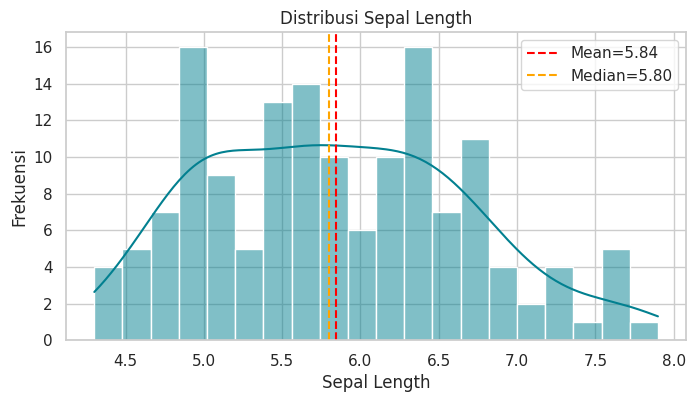

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(
    df['sepal_length'],
    kde=True,
    color='#028090',
    bins=20,
    ax=ax
)

ax.axvline(
    df['sepal_length'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean={df['sepal_length'].mean():.2f}"
)

ax.axvline(
    df['sepal_length'].median(),
    color='orange',
    linestyle='--',
    label=f"Median={df['sepal_length'].median():.2f}"
)

ax.set_title('Distribusi Sepal Length')
ax.set_xlabel('Sepal Length')
ax.set_ylabel('Frekuensi')
ax.legend()

plt.show()

# Boxplot per Spesies

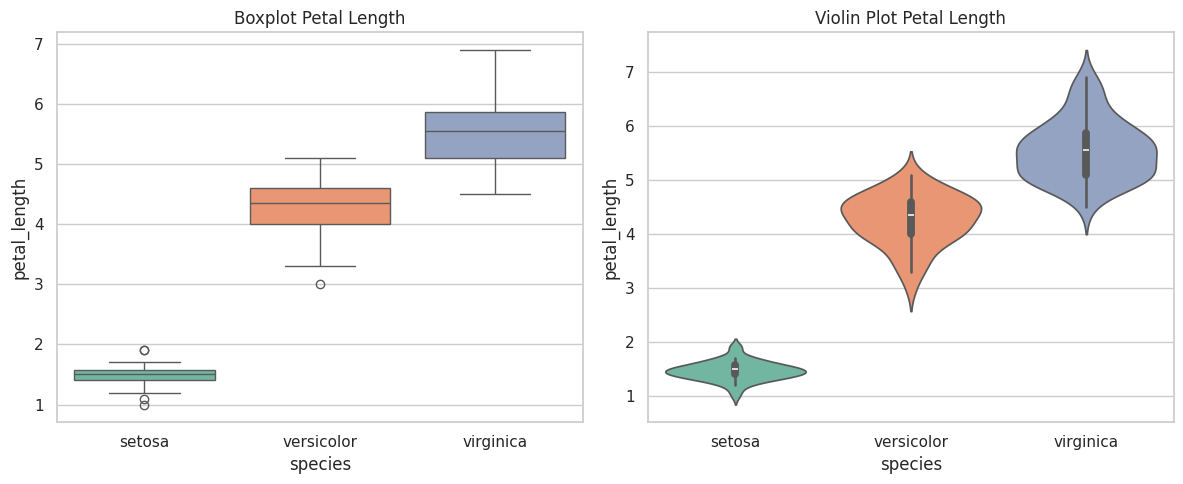

,min,max,mean,median,std
species,,,,,
setosa,1.0,1.9,1.462,1.50,0.174
versicolor,3.0,5.1,4.260,4.35,0.470
virginica,4.5,6.9,5.552,5.55,0.552


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(
    data=df,
    x='species',
    y='petal_length',
    hue='species',
    palette='Set2',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Boxplot Petal Length')

sns.violinplot(
    data=df,
    x='species',
    y='petal_length',
    hue='species',
    palette='Set2',
    inner='box',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Violin Plot Petal Length')

plt.tight_layout()
plt.show()

summary_petal = df.groupby('species')['petal_length'].agg(
    ['min', 'max', 'mean', 'median', 'std']
).round(3)

summary_petal

# Matriks Korelasi Pearson

In [16]:
corr = df.drop('species', axis=1).corr(method='pearson')

print(corr.round(3))

mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)

max_pair = corr_masked.stack().idxmax()
min_pair = corr_masked.stack().idxmin()

print(f'Korelasi tertinggi: {max_pair} = {corr.loc[max_pair]:.3f}')
print(f'Korelasi terendah : {min_pair} = {corr.loc[min_pair]:.3f}')

              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000
Korelasi tertinggi: ('petal_width', 'petal_length') = 0.963
Korelasi terendah : ('petal_length', 'sepal_width') = -0.428


# Scatter Plot & Heatmap

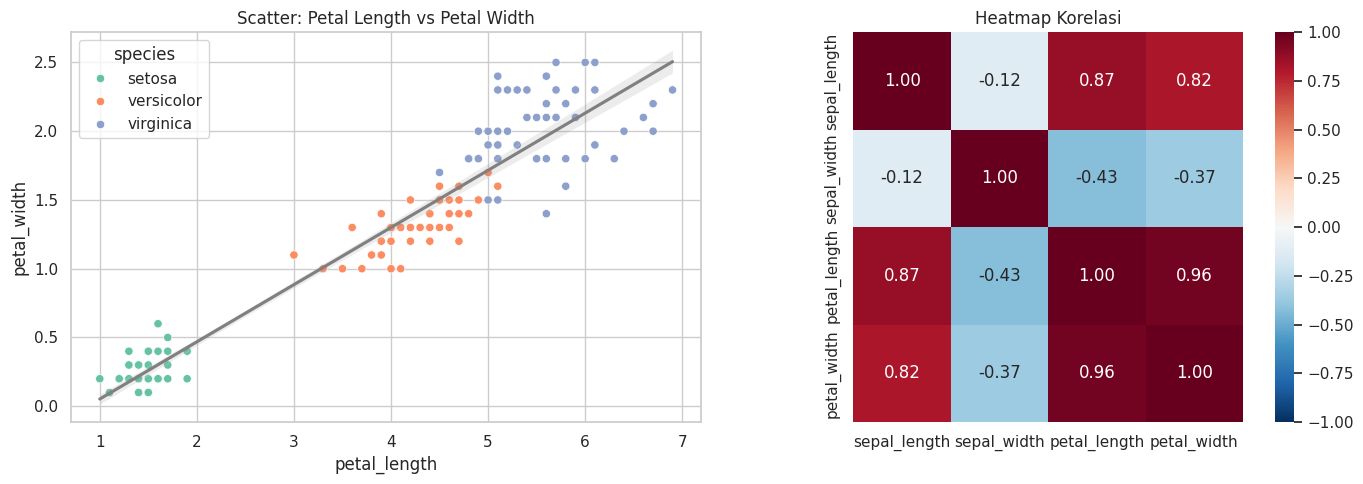

Pearson r  = 0.9629 (p = 0.000000)
Spearman ρ = 0.9377 (p = 0.000000)


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
    hue='species',
    palette='Set2',
    ax=axes[0]
)

sns.regplot(
    data=df,
    x='petal_length',
    y='petal_width',
    scatter=False,
    color='gray',
    ax=axes[0]
)

axes[0].set_title('Scatter: Petal Length vs Petal Width')

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[1]
)

axes[1].set_title('Heatmap Korelasi')

plt.tight_layout()
plt.show()

x = df['petal_length']
y = df['petal_width']

r, p_r = stats.pearsonr(x, y)
rho, p_s = stats.spearmanr(x, y)

print(f'Pearson r  = {r:.4f} (p = {p_r:.6f})')
print(f'Spearman ρ = {rho:.4f} (p = {p_s:.6f})')

## Kesimpulan

Pada praktikum Pertemuan 4 ini, saya mempelajari statistika dasar dan analisis data menggunakan dataset Iris. Tahapan yang dilakukan meliputi load dan inspeksi dataset, perhitungan statistik deskriptif, analisis distribusi menggunakan histogram dan KDE, visualisasi boxplot dan violin plot, serta analisis hubungan antar variabel menggunakan korelasi Pearson, scatter plot, dan heatmap.

Dari hasil analisis, dapat dilihat bahwa setiap spesies Iris memiliki karakteristik ukuran bunga yang berbeda. Spesies setosa memiliki petal_length paling kecil, sedangkan virginica memiliki nilai petal_length yang cenderung paling besar. Selain itu, variabel petal_length dan petal_width memiliki hubungan positif yang sangat kuat.